In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
X = np.array([1,2,3,4,5]).reshape(-1,1) #numpy needs 2d for matrix computations, so we use reshape(-1,1)
X

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [ ]:
y = np.array([40,50,50,60,70])
y

array([40, 50, 50, 60, 70])

In [ ]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
print("Intercept", model.intercept_)
print("Slope:", model.coef_[0])

Intercept 33.0
Slope: 7.0


In [ ]:
new_data = np.array([[6]])
predicted_mark = model.predict(new_data)
predicted_mark

array([75.])

In [ ]:
y_pred = model.predict(X)
y_pred

array([40., 47., 54., 61., 68.])

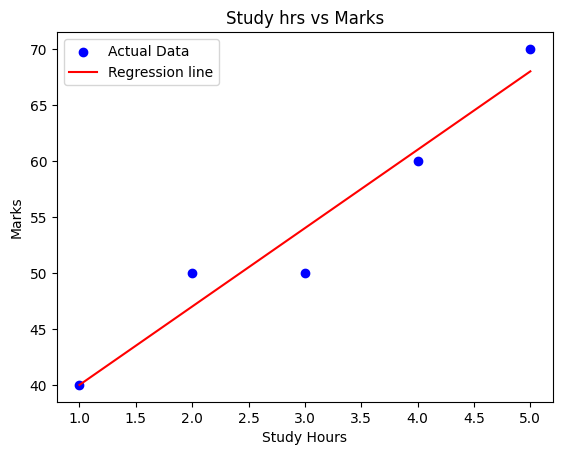

In [ ]:
plt.scatter(X,y, color = "blue", label = "Actual Data")
plt.plot(X, y_pred, color = "red", label = "Regression line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study hrs vs Marks")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mse)

In [ ]:
mae,mse,r2,rmse



(2.0, 6.0, 0.9423076923076923, np.float64(2.449489742783178))

# 2nd example

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
data = {
    "Study_Hours": [1,2,3,4,5,6,7,8,9,10],
    "Marks":[32,38,43,50,54,61,68,73,81,88]
}

In [ ]:
df = pd.DataFrame(data)

In [ ]:
X = df["Study_Hours"].values.reshape(-1,1)   # or df[["Studt_HOurs"]]
y = df["Marks"].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [ ]:
le = LinearRegression()


In [ ]:
le.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [ ]:
print("Intercept:",model.intercept_)
print("Slope:",model.coef_[0])
print("ACtual values:", y_test)
print("PRedicted values:",y_pred)

Intercept: 33.0
Slope: 7.0
ACtual values: [81 38]
PRedicted values: [96. 47.]


In [ ]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Absolute Error: 12.0
Mean Squared Error: 153.0
RMSE: 12.36931687685298
R2 Score: 0.6690102758247701


# Multiple Linear Regression

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression


In [ ]:
data  = {
    "Study_Hours": [2,3,4,5,6,7,8,9],
    "Attendance": [60,65,70,75,80,85,90,95],
    "Assignment_Score":[50,55,58,65,70,74,80,88],  # add study week and then run
    "Study_Week": [1,2,3,4,5,6,7,8],
    "Final_Marks": [42,48,54,61,73,71,81,89]
}

In [ ]:
df = pd.DataFrame(data)
X = df[["Study_Hours","Attendance","Assignment_Score","Study_Week"]] #added study week here
y = df["Final_Marks"]

In [ ]:
model = LinearRegression()
model.fit(X,y)
print("Intercept",model.intercept_)

Intercept -24.521271271271345


In [ ]:
coefficient_table = pd.DataFrame({
    "Feature":
X.columns,
    "Coefficient": model.coef_})

In [ ]:
print(coefficient_table)

            Feature  Coefficient
0       Study_Hours     0.089506
1        Attendance     0.447531
2  Assignment_Score     0.797297
3        Study_Week     0.089506


In [ ]:
new_Student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [82],
    "Assignment_Score": [72],
    "Study_Week": [2]
})

In [ ]:
prediction = model.predict(new_Student)
print("Predicted final mark:", prediction[0])

Predicted final mark: 70.2977143810477


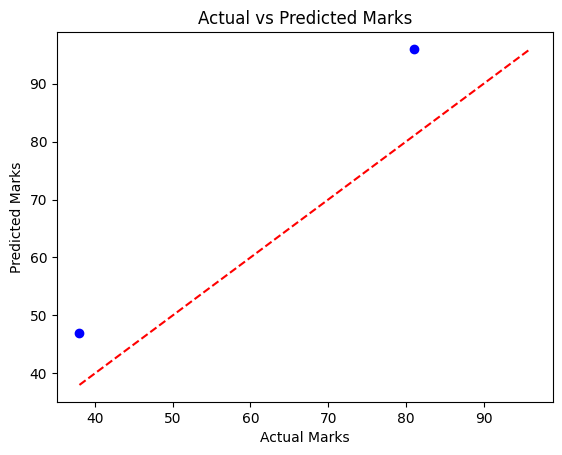

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred, color = "blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], color = "red", linestyle = "--")

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()

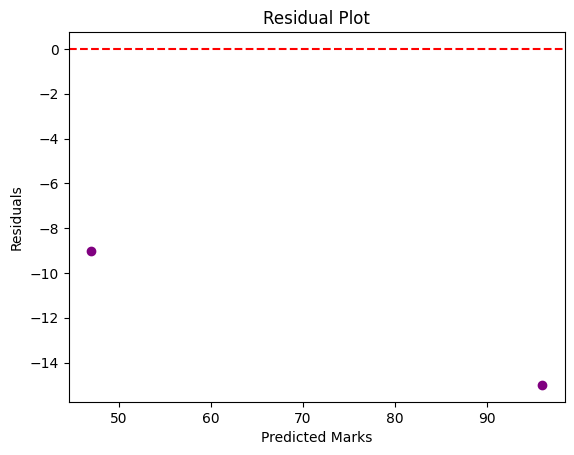

In [ ]:
#residual plot
residuals = y_test - y_pred
plt.scatter(y_pred,residuals,color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")
plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# working with label data

In [ ]:
import pandas as pd
data = {
    "Size":[800,1000,1200,1500,1800],
    "Location":["Rural","Urban","Rural","Urban","Urban"],
    "Price":[30,50,42,72,85]
}

df = pd.DataFrame(data)

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns = ["Location"],
    drop_first = True,
    dtype = int
)
print(df_encoded)


   Size  Price  Location_Urban
0   800     30               0
1  1000     50               1
2  1200     42               0
3  1500     72               1
4  1800     85               1


# task 2, creating a dataset u=in csv file'

In [ ]:
import pandas as pd
data  = {
    "Study_Hours": [2,3,4,5,6,7,8,9],
    "Attendance": [60,65,70,75,80,85,90,95],
    "Assignment_Score":[50,55,58,65,70,74,80,88],  # add study week and then run
    "Study_Week": [14,21,28,35,42,49,56,63],
    "Final_Marks": [42,48,54,61,73,71,81,89]
}

df = pd.DataFrame(data)
df.to_csv('my_dataset.csv',index = False)

In [ ]:
df = pd.read_csv("my_dataset.csv")
print(df)

   Study_Hours  Attendance  Assignment_Score  Study_Week  Final_Marks
0            2          60                50          14           42
1            3          65                55          21           48
2            4          70                58          28           54
3            5          75                65          35           61
4            6          80                70          42           73
5            7          85                74          49           71
6            8          90                80          56           81
7            9          95                88          63           89
